In [60]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [62]:
df_arm = pd.read_csv("indices_manzana_armenia.csv")
df_cali = pd.read_csv("indices_manzana_cali.csv")
df_per = pd.read_csv("indices_manzana_pereira.csv")

print("Armenia:", df_arm.shape)
print("Cali:", df_cali.shape)
print("Pereira:", df_per.shape)

Armenia: (3190, 7)
Cali: (13617, 7)
Pereira: (3988, 7)


In [63]:
features = [
    "IND_SERVICIOS",
    "IND_EDUCACION",
    "IND_LABORAL",
    "IND_POBREZA_HAB"
]

In [64]:
X_arm = df_arm[features].copy()
X_cali = df_cali[features].copy()
X_per = df_per[features].copy()

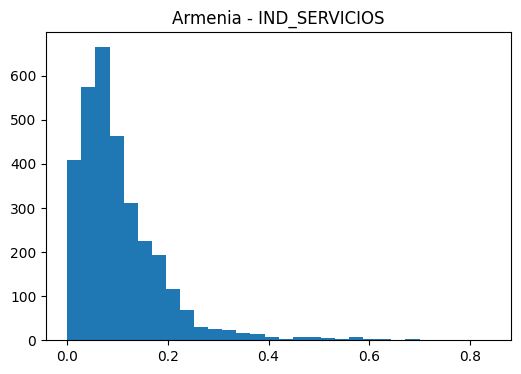

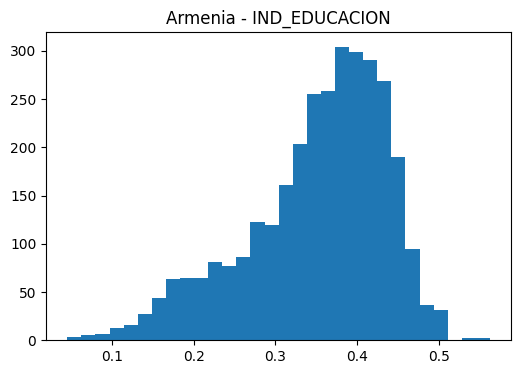

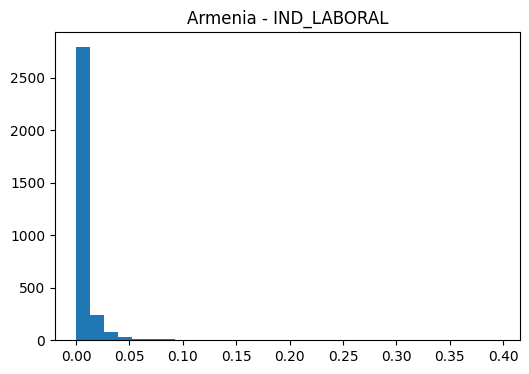

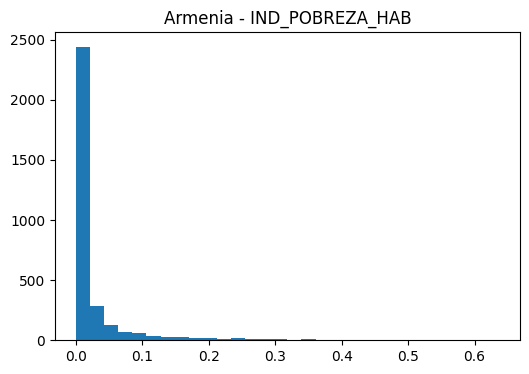

In [65]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_arm[col], bins=30)
    
    plt.title(f"Armenia - {col}")
    
    plt.show()

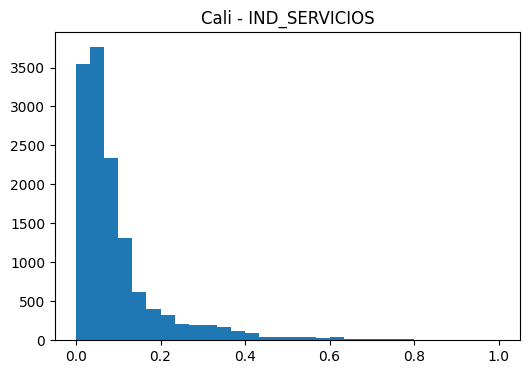

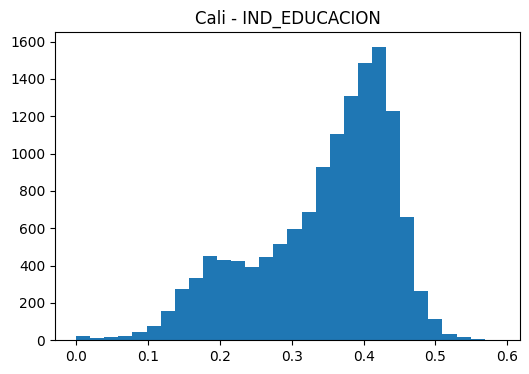

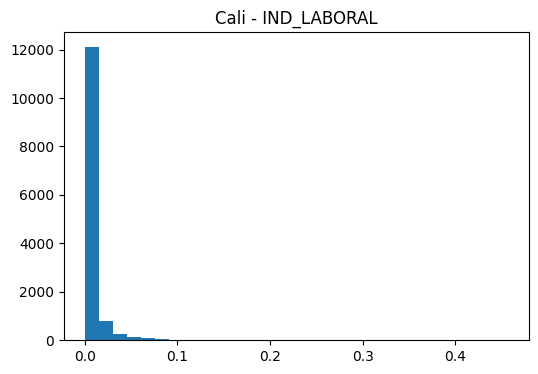

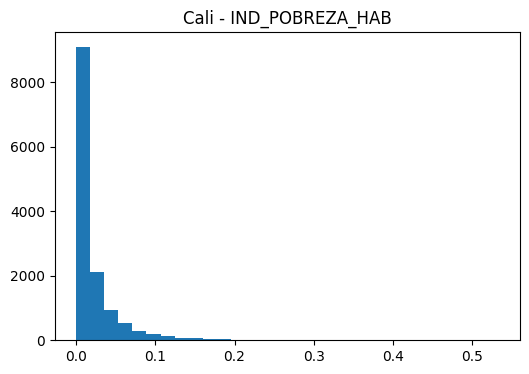

In [66]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_cali[col], bins=30)
    
    plt.title(f"Cali - {col}")
    
    plt.show()

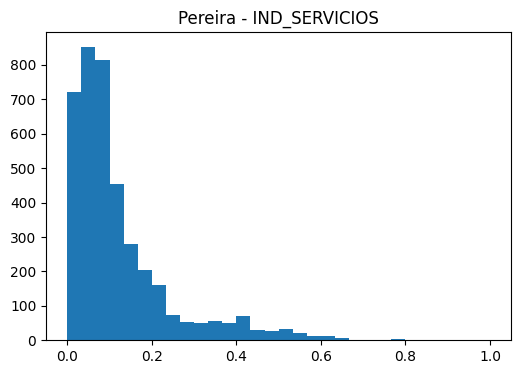

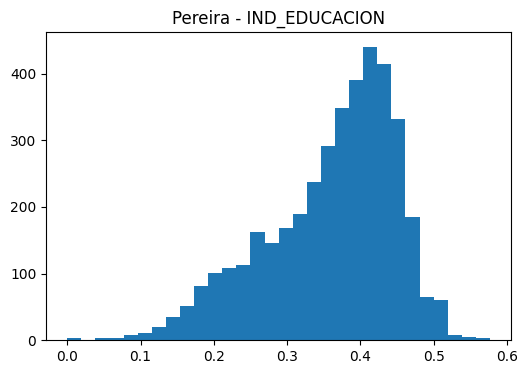

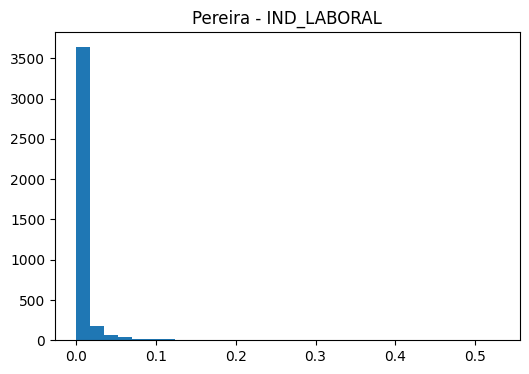

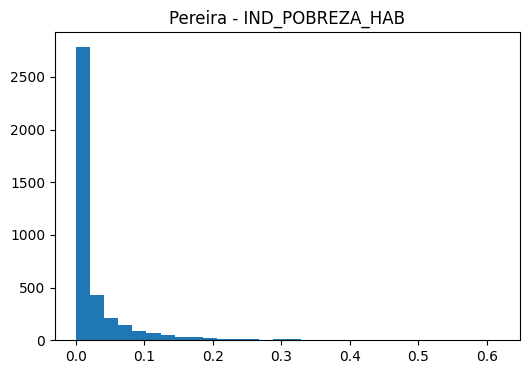

In [67]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_per[col], bins=30)
    
    plt.title(f"Pereira - {col}")
    
    plt.show()

In [68]:
scaler_arm = StandardScaler()
X_arm_scaled = scaler_arm.fit_transform(X_arm)

scaler_cali = StandardScaler()
X_cali_scaled = scaler_cali.fit_transform(X_cali)

scaler_per = StandardScaler()
X_per_scaled = scaler_per.fit_transform(X_per)

In [69]:
inertia_arm = []
K_range = range(2,10)

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X_arm_scaled)
    
    inertia_arm.append(kmeans.inertia_)

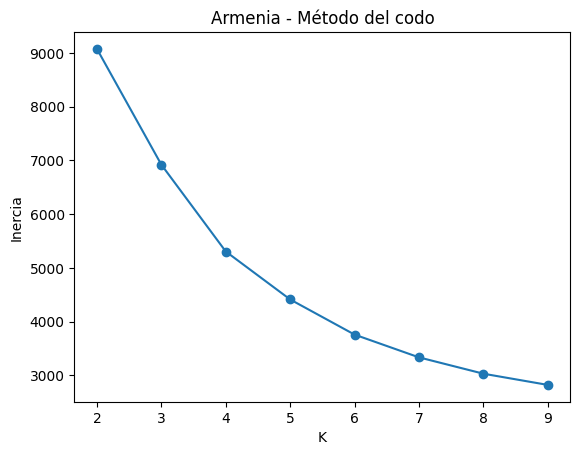

In [70]:
plt.plot(K_range, inertia_arm, marker="o")

plt.title("Armenia - Método del codo")

plt.xlabel("K")
plt.ylabel("Inercia")

plt.show()

In [71]:
sil_scores_arm = []

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(X_arm_scaled)
    
    sil = silhouette_score(X_arm_scaled, labels)
    
    sil_scores_arm.append(sil)

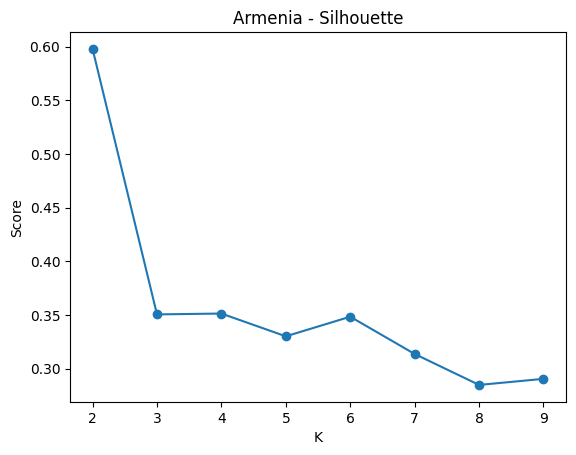

In [72]:
plt.plot(K_range, sil_scores_arm, marker="o")

plt.title("Armenia - Silhouette")

plt.xlabel("K")
plt.ylabel("Score")

plt.show()

In [73]:
kmeans_arm = KMeans(n_clusters=3, random_state=42, n_init=20)

df_arm["CLUSTER"] = kmeans_arm.fit_predict(X_arm_scaled)

In [74]:
perfil_arm = df_arm.groupby("CLUSTER")[features].mean()

perfil_arm

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB
CLUSTER,,,,
0,0.055553,0.250666,0.005261,0.005045
1,0.107251,0.395899,0.004117,0.015636
2,0.336086,0.425460,0.012513,0.214479


In [75]:
df_arm["CLUSTER"].value_counts(normalize=True)

CLUSTER
1    0.618182
0    0.322884
2    0.058934
Name: proportion, dtype: float64

In [76]:
df_arm_export = df_arm[
    ["COD_DANE_ANM","CLUSTER"] + features
]

df_arm_export.to_csv(
    "clusters_armenia.csv",
    index=False
)

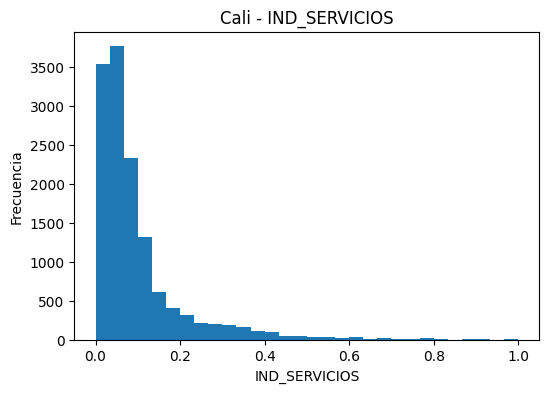

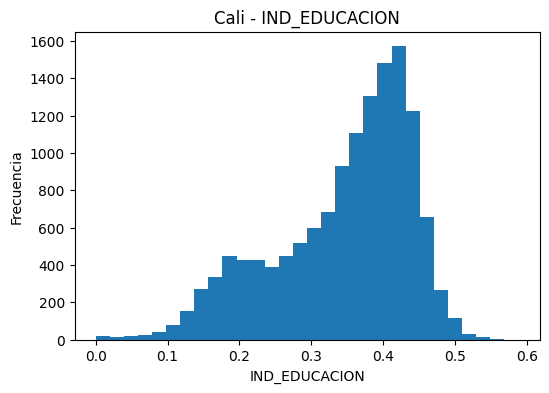

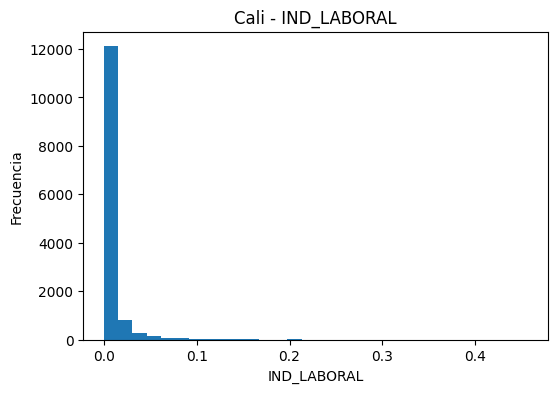

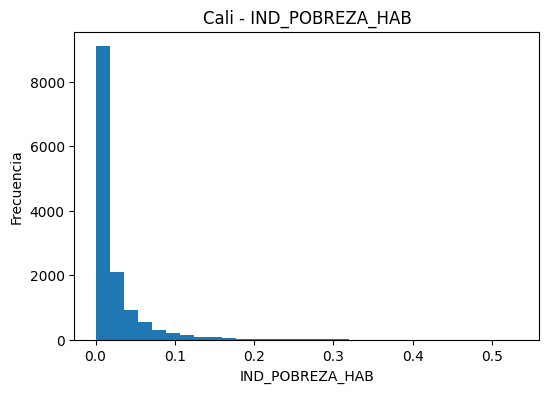

In [77]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_cali[col], bins=30)
    
    plt.title(f"Cali - {col}")
    
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    
    plt.show()

In [78]:
scaler_cali = StandardScaler()

X_cali_scaled = scaler_cali.fit_transform(X_cali)

In [79]:
inertia_cali = []

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X_cali_scaled)
    
    inertia_cali.append(kmeans.inertia_)

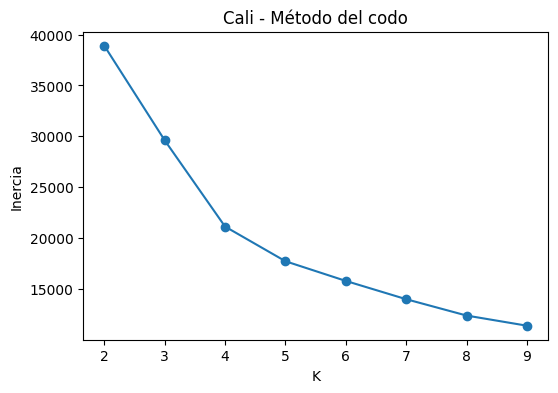

In [80]:
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertia_cali, marker="o")
plt.title("Cali - Método del codo")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.xticks(list(K_range))
plt.show()

In [81]:
sil_scores_cali = []

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(X_cali_scaled)
    
    sil = silhouette_score(X_cali_scaled, labels)
    
    sil_scores_cali.append(sil)

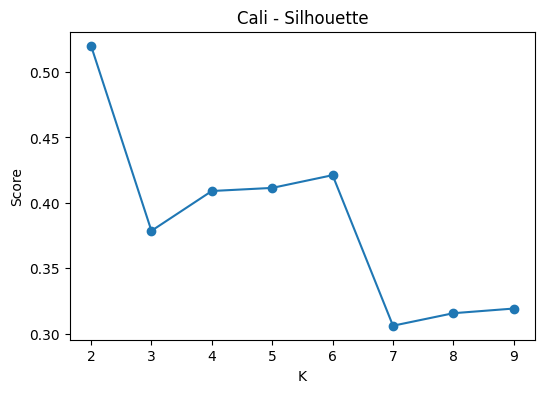

In [82]:
plt.figure(figsize=(6,4))
plt.plot(list(K_range), sil_scores_cali, marker="o")
plt.title("Cali - Silhouette")
plt.xlabel("K")
plt.ylabel("Score")
plt.xticks(list(K_range))
plt.show()

In [83]:
kmeans_cali = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df_cali["CLUSTER"] = kmeans_cali.fit_predict(X_cali_scaled)

In [84]:
perfil_cali = df_cali.groupby("CLUSTER")[features].mean()

perfil_cali

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB
CLUSTER,,,,
0,0.037770,0.223972,0.004883,0.004905
1,0.086904,0.394157,0.007939,0.016567
2,0.366766,0.427738,0.004868,0.103398


In [85]:
df_cali["CLUSTER"].value_counts(normalize=True)

CLUSTER
1    0.601307
0    0.306015
2    0.092678
Name: proportion, dtype: float64

In [86]:
df_cali_export = df_cali[
    ["COD_DANE_ANM","CLUSTER"] + features
]

df_cali_export.to_csv("clusters_cali.csv", index=False)

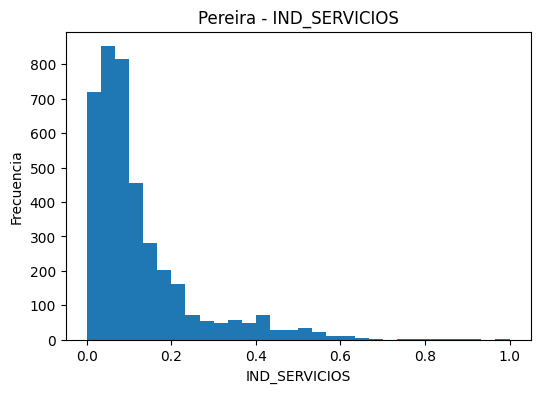

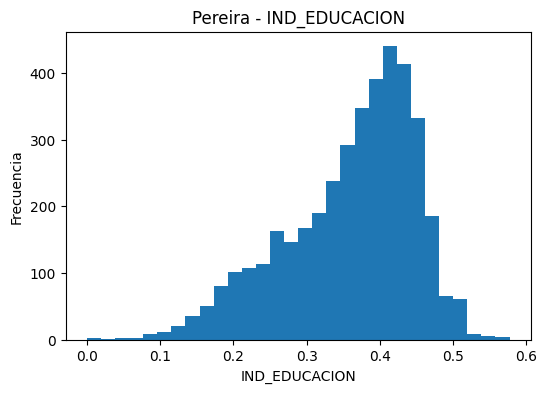

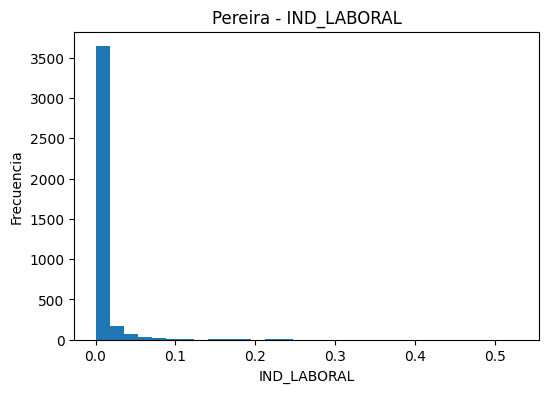

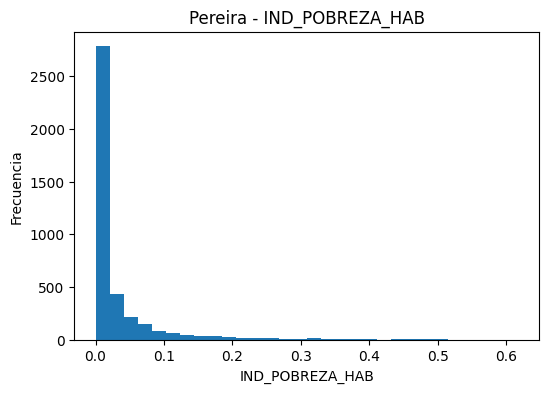

In [87]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_per[col], bins=30)
    
    plt.title(f"Pereira - {col}")
    
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    
    plt.show()

In [88]:
scaler_per = StandardScaler()

X_per_scaled = scaler_per.fit_transform(X_per)

In [89]:
K_range = range(2,10)

In [90]:
inertia_per = []

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_per_scaled)
    
    inertia_per.append(kmeans.inertia_)

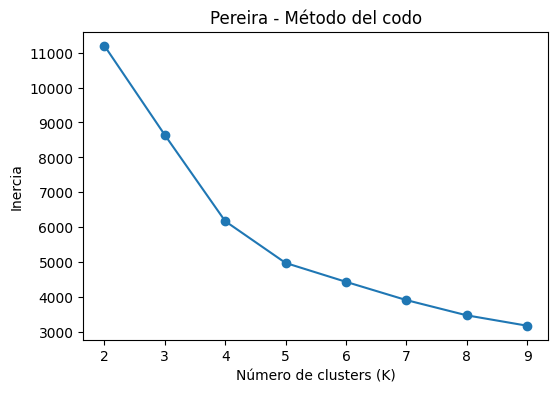

In [91]:
plt.figure(figsize=(6,4))

plt.plot(list(K_range), inertia_per, marker="o")

plt.title("Pereira - Método del codo")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")

plt.xticks(list(K_range))

plt.show()

In [92]:
sil_scores_per = []

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_per_scaled)
    
    sil = silhouette_score(X_per_scaled, labels)
    
    sil_scores_per.append(sil)

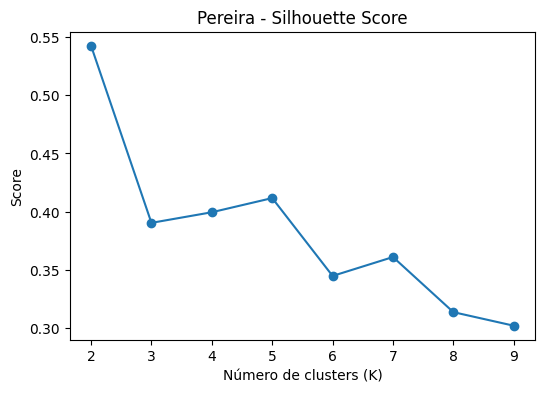

In [93]:
plt.figure(figsize=(6,4))

plt.plot(list(K_range), sil_scores_per, marker="o")

plt.title("Pereira - Silhouette Score")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Score")

plt.xticks(list(K_range))

plt.show()

In [94]:
kmeans_per = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df_per["CLUSTER"] = kmeans_per.fit_predict(X_per_scaled)

In [95]:
perfil_per = df_per.groupby("CLUSTER")[features].mean()

perfil_per

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB
CLUSTER,,,,
0,0.107762,0.403860,0.003324,0.018200
1,0.403209,0.435589,0.011946,0.174696
2,0.058170,0.250398,0.010614,0.006022


In [96]:
perfil_per = df_per.groupby("CLUSTER")[features].mean()

perfil_per

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB
CLUSTER,,,,
0,0.107762,0.403860,0.003324,0.018200
1,0.403209,0.435589,0.011946,0.174696
2,0.058170,0.250398,0.010614,0.006022


In [97]:
df_per_export = df_per[
    ["COD_DANE_ANM","CLUSTER"] + features
]

df_per_export.to_csv(
    "clusters_pereira.csv",
    index=False
)

In [98]:
perfil_cali = df_cali.groupby("CLUSTER")[features].mean()
perfil_cali

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB
CLUSTER,,,,
0,0.037770,0.223972,0.004883,0.004905
1,0.086904,0.394157,0.007939,0.016567
2,0.366766,0.427738,0.004868,0.103398


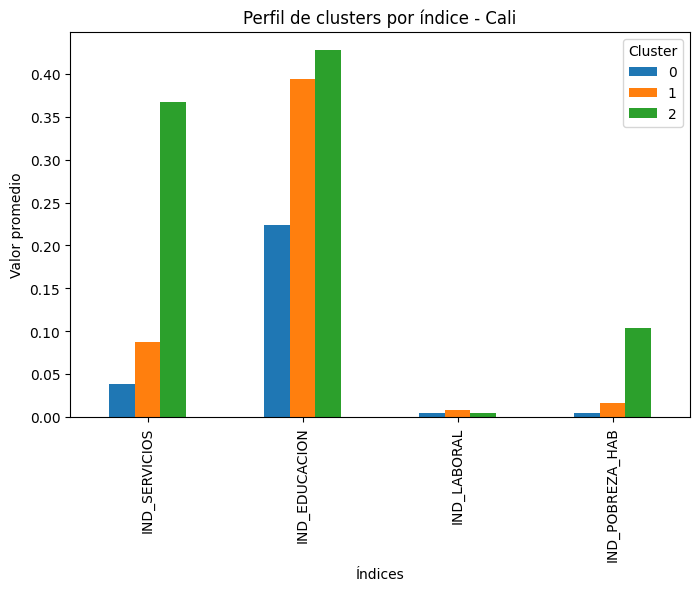

In [102]:
import matplotlib.pyplot as plt

perfil_cali.T.plot(kind="bar", figsize=(8,5))

plt.title("Perfil de clusters por índice - Cali")
plt.xlabel("Índices")
plt.ylabel("Valor promedio")

plt.legend(title="Cluster")

plt.show()

AÑADIR CLUSTERS A EXCEL COMPLETO CON DATA Y GEOREFERENCIACIÓN

In [1]:
import pandas as pd

df_censo = pd.read_csv("censo_georeferencia_armenia.csv")

print("Filas y columnas:")
print(df_censo.shape)

print("\nColumnas:")
print(df_censo.columns)

Filas y columnas:
(269280, 48)

Columnas:
Index(['COD_DANE_ANM', 'HA_TOT_PER', 'H_NRO_CUARTOS', 'H_NRO_DORMIT',
       'PA1_CALIDAD_SERV', 'PA_ASISTENCIA', 'PA_LO_ATENDIERON', 'P_ALFABETA',
       'P_EDADR', 'P_ENFERMO', 'P_NIVEL_ANOSR', 'P_NROHOG', 'P_NRO_PER',
       'P_PARENTESCOR', 'P_SEXO', 'P_TRABAJO', 'UA1_LOCALIDAD', 'UA_CLASE',
       'U_DPTO', 'U_MPIO', 'U_MZA', 'U_SECC_URB', 'U_SECT_URB', 'U_VIVIENDA',
       'VA_EE', 'VB_ACU', 'VC_ALC', 'VD_GAS', 'VE_RECBAS', 'VF_INTERNET',
       'V_CON_OCUP', 'V_MAT_PARED', 'V_MAT_PISO', 'V_TIPO_VIV', 'DPTO_MPIO_x',
       'DPTO_CCDGO', 'MPIO_CCDGO', 'CLAS_CCDGO', 'CPOB_CCDGO', 'COD_SECC',
       'MANZ_CCNCT', 'COD_AG', 'SHAPE_Leng', 'SHAPE_Area', 'MANZ_CCDGO',
       'DPTO_MPIO_y', 'GEOM_WKT', 'DPTO_MPIO'],
      dtype='str')


In [2]:
df_cluster = pd.read_csv("clusters_armenia.csv")

print("Filas cluster:")
print(df_cluster.shape)

print("\nColumnas cluster:")
print(df_cluster.columns)

Filas cluster:
(3190, 6)

Columnas cluster:
Index(['COD_DANE_ANM', 'CLUSTER', 'IND_SERVICIOS', 'IND_EDUCACION',
       'IND_LABORAL', 'IND_POBREZA_HAB'],
      dtype='str')


In [3]:
df_final = df_censo.merge(
    df_cluster[["COD_DANE_ANM","CLUSTER"]],
    on="COD_DANE_ANM",
    how="left"
)

In [4]:
print("Filas finales:")
print(df_final.shape)

print("\nClusters nulos (join fallido):")
print(df_final["CLUSTER"].isna().sum())

Filas finales:
(269280, 49)

Clusters nulos (join fallido):
0


In [6]:
cluster_counts = df_final["CLUSTER"].value_counts().sort_index()

cluster_pct = df_final["CLUSTER"].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    "Cantidad_manzanas": cluster_counts,
    "Porcentaje": cluster_pct.round(2)
})

print("\nDistribución de clusters:")
print(cluster_summary)


Distribución de clusters:
         Cantidad_manzanas  Porcentaje
CLUSTER                               
0                    94472       35.08
1                   155806       57.86
2                    19002        7.06


In [7]:
df_final.to_csv(
    "armenia_clusters_final.csv",
    index=False
)

print("Archivo guardado.")

Archivo guardado.


In [8]:
import pandas as pd

df_censo = pd.read_csv("censo_georeferencia_pereira.csv")

print("Filas y columnas:")
print(df_censo.shape)

print("\nColumnas:")
print(df_censo.columns)

Filas y columnas:
(377436, 48)

Columnas:
Index(['COD_DANE_ANM', 'HA_TOT_PER', 'H_NRO_CUARTOS', 'H_NRO_DORMIT',
       'PA1_CALIDAD_SERV', 'PA_ASISTENCIA', 'PA_LO_ATENDIERON', 'P_ALFABETA',
       'P_EDADR', 'P_ENFERMO', 'P_NIVEL_ANOSR', 'P_NROHOG', 'P_NRO_PER',
       'P_PARENTESCOR', 'P_SEXO', 'P_TRABAJO', 'UA1_LOCALIDAD', 'UA_CLASE',
       'U_DPTO', 'U_MPIO', 'U_MZA', 'U_SECC_URB', 'U_SECT_URB', 'U_VIVIENDA',
       'VA_EE', 'VB_ACU', 'VC_ALC', 'VD_GAS', 'VE_RECBAS', 'VF_INTERNET',
       'V_CON_OCUP', 'V_MAT_PARED', 'V_MAT_PISO', 'V_TIPO_VIV', 'DPTO_MPIO_x',
       'DPTO_CCDGO', 'MPIO_CCDGO', 'CLAS_CCDGO', 'CPOB_CCDGO', 'COD_SECC',
       'MANZ_CCNCT', 'COD_AG', 'SHAPE_Leng', 'SHAPE_Area', 'MANZ_CCDGO',
       'DPTO_MPIO_y', 'GEOM_WKT', 'DPTO_MPIO'],
      dtype='str')


In [9]:
df_cluster = pd.read_csv("clusters_pereira.csv")

print("Filas cluster:")
print(df_cluster.shape)

print("\nColumnas cluster:")
print(df_cluster.columns)

Filas cluster:
(3988, 6)

Columnas cluster:
Index(['COD_DANE_ANM', 'CLUSTER', 'IND_SERVICIOS', 'IND_EDUCACION',
       'IND_LABORAL', 'IND_POBREZA_HAB'],
      dtype='str')


In [10]:
df_final = df_censo.merge(
    df_cluster[["COD_DANE_ANM","CLUSTER"]],
    on="COD_DANE_ANM",
    how="left"
)

In [11]:
print("Filas finales:")
print(df_final.shape)

print("\nClusters nulos (join fallido):")
print(df_final["CLUSTER"].isna().sum())

Filas finales:
(377436, 49)

Clusters nulos (join fallido):
0


In [12]:
cluster_counts = df_final["CLUSTER"].value_counts().sort_index()

cluster_pct = df_final["CLUSTER"].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    "Cantidad_manzanas": cluster_counts,
    "Porcentaje": cluster_pct.round(2)
})

print("\nDistribución de clusters:")
print(cluster_summary)


Distribución de clusters:
         Cantidad_manzanas  Porcentaje
CLUSTER                               
0                   220735       58.48
1                    32189        8.53
2                   124512       32.99


In [13]:
df_final.to_csv(
    "pereira_clusters_final.csv",
    index=False
)

print("Archivo guardado.")

Archivo guardado.


In [14]:
import pandas as pd

df_censo = pd.read_csv("censo_georeferencia_cali.csv")

print("Filas y columnas:")
print(df_censo.shape)

print("\nColumnas:")
print(df_censo.columns)

Filas y columnas:
(1802659, 48)

Columnas:
Index(['COD_DANE_ANM', 'HA_TOT_PER', 'H_NRO_CUARTOS', 'H_NRO_DORMIT',
       'PA1_CALIDAD_SERV', 'PA_ASISTENCIA', 'PA_LO_ATENDIERON', 'P_ALFABETA',
       'P_EDADR', 'P_ENFERMO', 'P_NIVEL_ANOSR', 'P_NROHOG', 'P_NRO_PER',
       'P_PARENTESCOR', 'P_SEXO', 'P_TRABAJO', 'UA1_LOCALIDAD', 'UA_CLASE',
       'U_DPTO', 'U_MPIO', 'U_MZA', 'U_SECC_URB', 'U_SECT_URB', 'U_VIVIENDA',
       'VA_EE', 'VB_ACU', 'VC_ALC', 'VD_GAS', 'VE_RECBAS', 'VF_INTERNET',
       'V_CON_OCUP', 'V_MAT_PARED', 'V_MAT_PISO', 'V_TIPO_VIV', 'DPTO_MPIO_x',
       'DPTO_CCDGO', 'MPIO_CCDGO', 'CLAS_CCDGO', 'CPOB_CCDGO', 'COD_SECC',
       'MANZ_CCNCT', 'COD_AG', 'SHAPE_Leng', 'SHAPE_Area', 'MANZ_CCDGO',
       'DPTO_MPIO_y', 'GEOM_WKT', 'DPTO_MPIO'],
      dtype='str')


In [15]:
df_cluster = pd.read_csv("clusters_cali.csv")

print("Filas cluster:")
print(df_cluster.shape)

print("\nColumnas cluster:")
print(df_cluster.columns)

Filas cluster:
(13617, 6)

Columnas cluster:
Index(['COD_DANE_ANM', 'CLUSTER', 'IND_SERVICIOS', 'IND_EDUCACION',
       'IND_LABORAL', 'IND_POBREZA_HAB'],
      dtype='str')


In [16]:
df_final = df_censo.merge(
    df_cluster[["COD_DANE_ANM","CLUSTER"]],
    on="COD_DANE_ANM",
    how="left"
)

In [17]:
print("Filas finales:")
print(df_final.shape)

print("\nClusters nulos (join fallido):")
print(df_final["CLUSTER"].isna().sum())

Filas finales:
(1802659, 49)

Clusters nulos (join fallido):
0


In [18]:
cluster_counts = df_final["CLUSTER"].value_counts().sort_index()

cluster_pct = df_final["CLUSTER"].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    "Cantidad_manzanas": cluster_counts,
    "Porcentaje": cluster_pct.round(2)
})

print("\nDistribución de clusters:")
print(cluster_summary)


Distribución de clusters:
         Cantidad_manzanas  Porcentaje
CLUSTER                               
0                   614344       34.08
1                  1090010       60.47
2                    98305        5.45


In [19]:
df_final.to_csv(
    "cali_clusters_final.csv",
    index=False
)

print("Archivo guardado.")

Archivo guardado.
